# 00 — Chronos-2 Sanity Check

Goal: confirm the local install works by reproducing the official Chronos-2 quickstart on the AutoGluon `electricity_price` dataset. Covariate-informed 24-step forecast; plot median + 80% band against ground truth.

See: [https://huggingface.co/amazon/chronos-2](https://huggingface.co/amazon/chronos-2)

Runs on CPU.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())

torch: 2.12.0 | cuda: False


In [2]:
context_df = pd.read_parquet('https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet')
test_df = pd.read_parquet('https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet')
future_df = test_df.drop(columns='target')
print('context:', context_df.shape, '| test:', test_df.shape)
context_df.head()

context: (51936, 5) | test: (24, 5)


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


In [3]:
pipeline = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')
print('model loaded')

model loaded


In [ ]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)
pred_df.head()

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-12-12 00:00:00,target,22.242920,18.673733,22.242920,25.403446
1,DE,2017-12-12 01:00:00,target,19.525616,14.904278,19.525616,23.316599
2,DE,2017-12-12 02:00:00,target,17.415369,12.209045,17.415369,21.776974
3,DE,2017-12-12 03:00:00,target,16.979256,11.165100,16.979256,21.435211
4,DE,2017-12-12 04:00:00,target,18.058651,12.096779,18.058651,23.166643


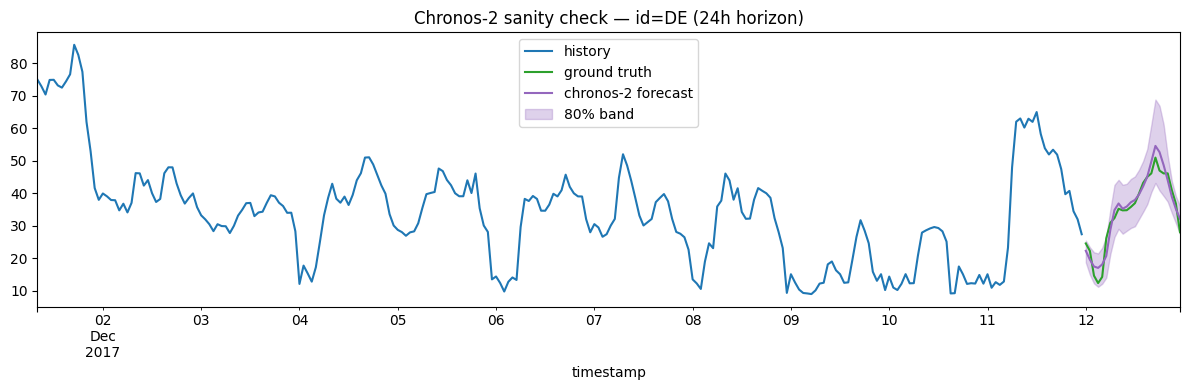

In [5]:
first_id = pred_df['id'].iloc[0]
ctx = context_df[context_df['id'] == first_id].set_index('timestamp')['target'].tail(256)
gt = test_df[test_df['id'] == first_id].set_index('timestamp')['target']
fc = pred_df[pred_df['id'] == first_id].set_index('timestamp')

fig, ax = plt.subplots(figsize=(12, 4))
ctx.plot(ax=ax, label='history', color='#1f77b4')
gt.plot(ax=ax, label='ground truth', color='#2ca02c')
fc['predictions'].plot(ax=ax, label='chronos-2 forecast', color='#9467bd')
ax.fill_between(fc.index, fc['0.1'], fc['0.9'], alpha=0.3, color='#9467bd', label='80% band')
ax.set_title(f'Chronos-2 sanity check — id={first_id} (24h horizon)')
ax.legend()
fig.tight_layout()
fig.savefig('../outputs/figures/00_sanity_check.png', dpi=120)
plt.show()

In [6]:
import numpy as np
joined = fc.join(gt.rename('actual'), how='inner')
mae = float(np.mean(np.abs(joined['actual'] - joined['predictions'])))
coverage = float(np.mean((joined['actual'] >= joined['0.1']) & (joined['actual'] <= joined['0.9'])))
print(f'MAE (median vs actual): {mae:.3f}')
print(f'80% PI coverage:        {coverage:.3f}  (target ~0.80)')

MAE (median vs actual): 2.457
80% PI coverage:        1.000  (target ~0.80)
